## PLOT RESULTS

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

In [2]:
from synco import run_pipeline, build_pipeline_config

In [ ]:
from pathlib import Path

CFG = {
    "paths": {
        "base": Path("data/DrugLogics"),
        "pipeline_runs": Path("data/DrugLogics/20250804/drabme_out"),
        "input": Path("data/input"),
        "output": None
    },
    "general": {
        "cell_lines": ['SNU81', 'CAR1', 'HT115', 'LS123', 'NCIH508', 'NCIH747', 'NCIH716', 'T84', 'SW1417', 'SW948', 'SW837', 'SW1463', 'SW1116', 'SW620', 'CL11', 'C2BBE1'],
        "run_date": "20250804",
        "verbose": True,
    },
    "compare": {
        "prediction_method": "DrugLogics",
        "threshold": 0.0,
        "synergy_column": "synergy",
        "analysis_mode": "cell_line"
    }
    # ADVANCE SETTINGS
    # "advanced": {    }
}End of interactive chart.
Min 0.0
Max 54.54545454545454

Accuracy
Missing:
0%
Distinct:
44%
Value histogram

Bar chart with 10 bars.
The chart has 1 X axis displaying Bin ranges. Data ranges from -0.09 to 9.
The chart has 1 Y axis displaying Bin frequencies. Data ranges from 0 to 5.
End of interactive chart.
45.45


In [7]:
# Build pipeline configuration
pipeline_config = build_pipeline_config(CFG)

# Pipeline execution
synco_results = run_pipeline(pipeline_config)

=== COMPARISON SUMMARY ===

Items in experimental data: 16
Items in predicted data: 16
Common items to compare: 16
Skipped from experimental: 0
Skipped from predicted: 0

=== GLOBAL RESULTS ===

Total comparisons: 176
Global matches: 127 (72.16%)
Global mismatches: 49 (27.84%)
Global True Positives: 103
Global True Negatives: 24
Global False Positives: 33
Global False Negatives: 16
Global Accuracy: 72.16%
Global Recall: 86.55%
Global Precision: 75.74%


In [8]:
cell_metrics = synco_results['synergy_comparison']
cell_metrics

,True Positive,True Negative,False Positive,False Negative,Total,Match,Mismatch,Match %,Mismatch %,Accuracy,Recall,Precision,ROC AUC,PR AUC,F1 Score
SW1417,6,3,2,0,11,9,2,81.818182,18.181818,81.82,100.00,75.00,0.800000,0.750000,0.857143
SW1463,5,2,4,0,11,7,4,63.636364,36.363636,63.64,100.00,55.56,0.666667,0.555556,0.714286
T84,8,0,0,3,11,8,3,72.727273,27.272727,72.73,72.73,100.00,0.000000,0.000000,0.000000
NCIH716,7,2,1,1,11,9,2,81.818182,18.181818,81.82,87.50,87.50,0.770833,0.856534,0.875000
NCIH747,6,2,1,2,11,8,3,72.727273,27.272727,72.73,75.00,85.71,0.708333,0.824675,0.800000
SW837,4,2,2,3,11,6,5,54.545455,45.454545,54.55,57.14,66.67,0.535714,0.653680,0.615385
LS123,9,0,1,1,11,9,2,81.818182,18.181818,81.82,90.00,90.00,0.450000,0.900909,0.900000
HT115,5,1,5,0,11,6,5,54.545455,45.454545,54.55,100.00,50.00,0.583333,0.500000,0.666667
SNU81,7,0,2,2,11,7,4,63.636364,36.363636,63.64,77.78,77.78,0.388889,0.786756,0.777778
C2BBE1,7,2,2,0,11,9,2,81.818182,18.181818,81.82,100.00,77.78,0.750000,0.777778,0.875000


In [14]:
combi_metrics = synco_results['synergy_comparison']
combi_metrics

,True Positive,True Negative,False Positive,False Negative,Total,Match,Mismatch,Match %,Mismatch %,Accuracy,Recall,Precision
CyclinD_inhibitors + mTOR_inhibitors,0,0,0,2,2,0,2,0.0,100.0,0.0,0.0,0.0
BCL2L1_inhibitors + mTOR_inhibitors,0,1,0,1,2,1,1,50.0,50.0,50.0,0.0,0.0
AKT_inhibitors + mTOR_inhibitors,0,1,0,1,2,1,1,50.0,50.0,50.0,0.0,0.0
BCL2_inhibitors + mTOR_inhibitors,1,0,1,0,2,1,1,50.0,50.0,50.0,100.0,50.0


### RING PLOTS

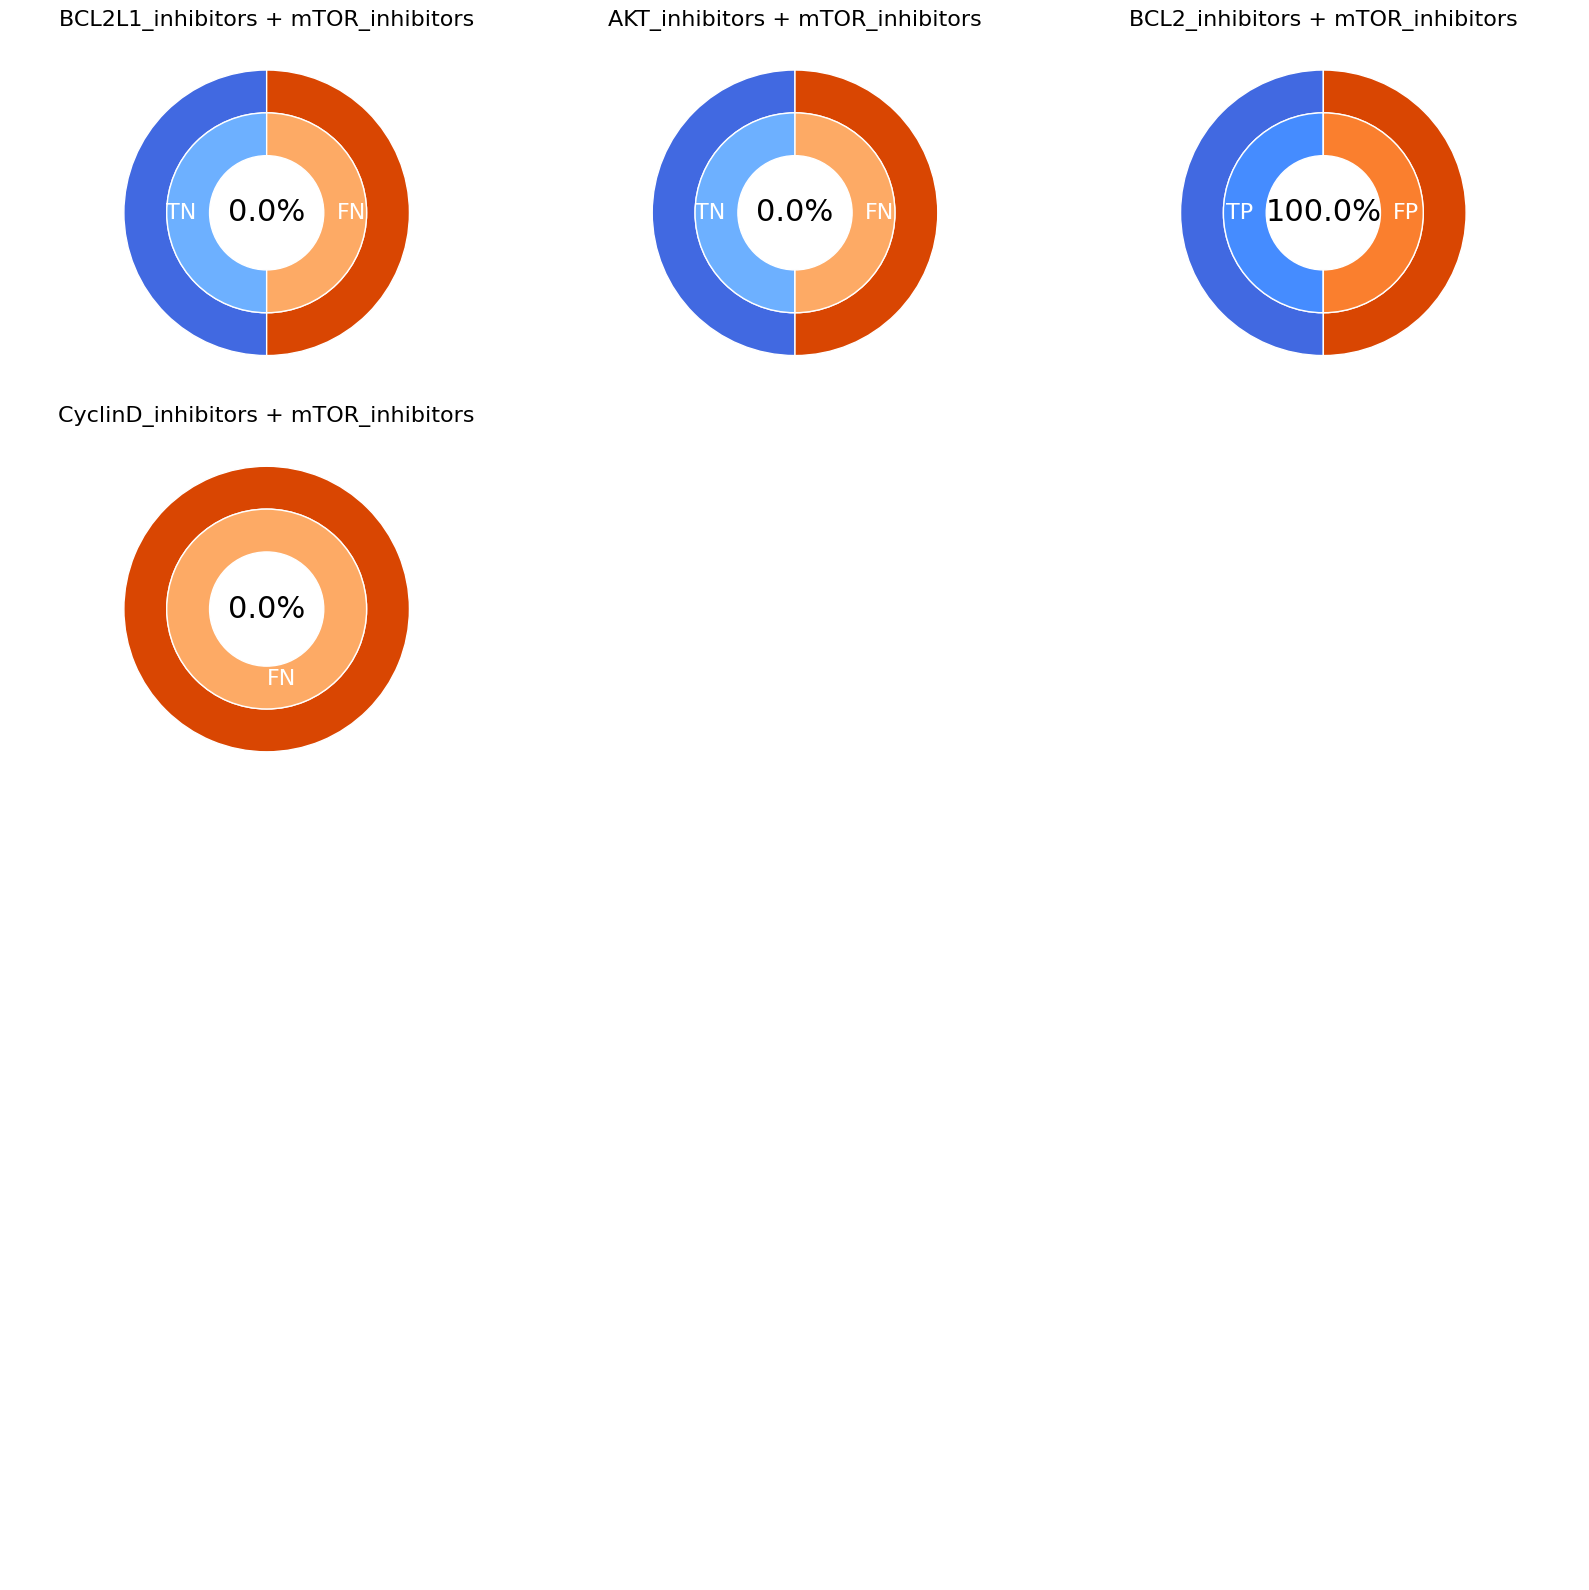

In [15]:
# RING PLOT BY DRUG COMBINATION /////////////////////////////////////////////

def plot_combination_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=22)

    # Title
    ax.set_title(f"{row.name}", fontsize=16)

# Plot all target combinations in a grid
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

# Sort combi_match_df by Recall
combi_match_df = combi_metrics.sort_values(by='Accuracy', ascending=False)

for ax, (_, row) in zip(axes, combi_match_df.iterrows()):
    plot_combination_rings(ax, row)

# Hide any unused subplots
for ax in axes[len(combi_match_df):]:
    ax.axis('off')

# Add legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
]

# Top right outside the plot
# fig.legend(handles=legend_elements, fontsize=14, loc='lowe right', bbox_to_anchor=(1.1, 0.9))

plt.tight_layout()
# plt.savefig(f"{plots_path}rings_combination.png", bbox_inches='tight')
plt.show()

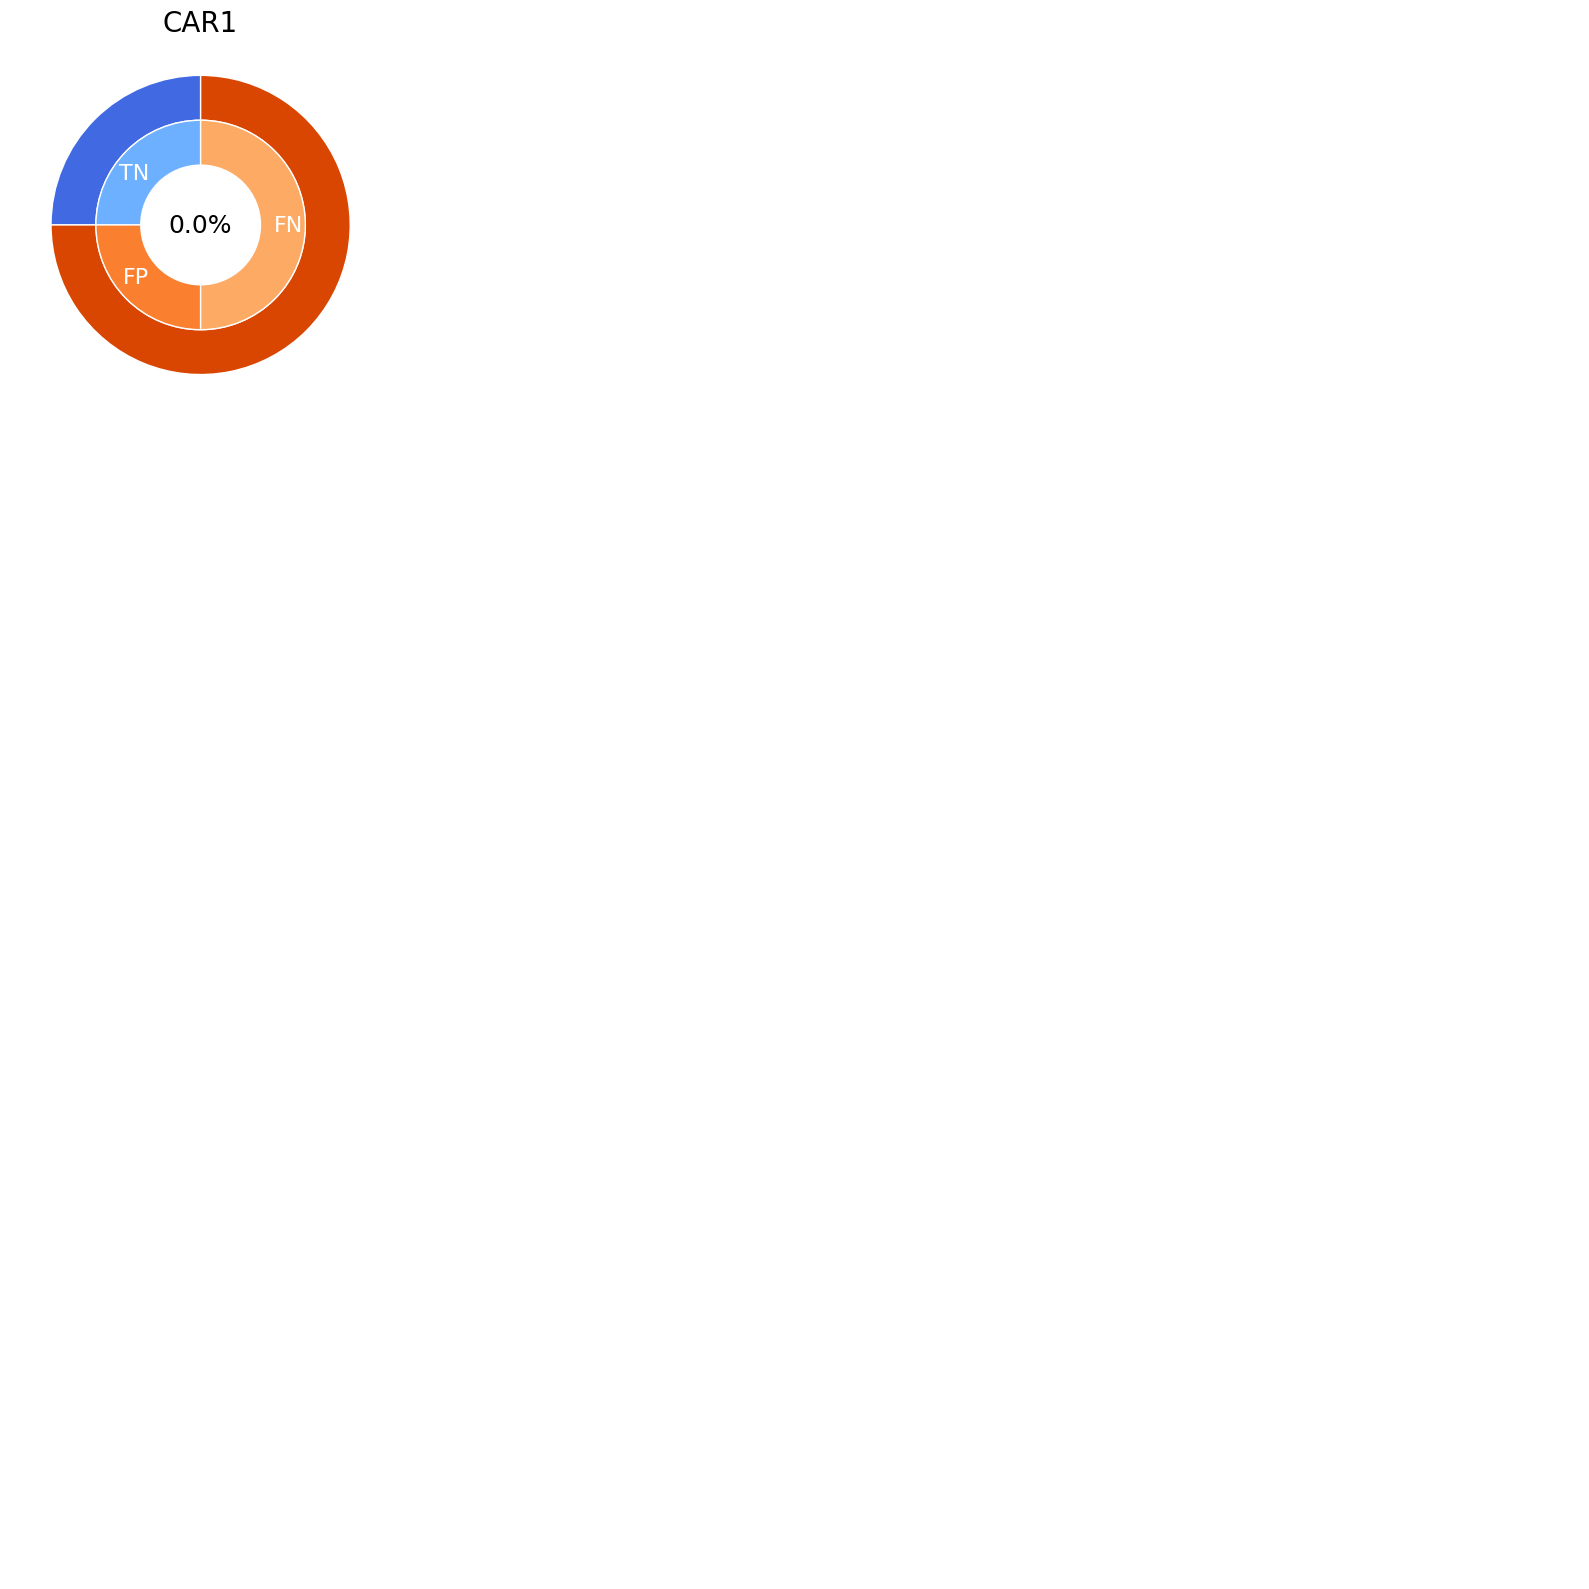

In [6]:
# RING PLOT BY CELL LINE /////////////////////////////////////////////

# cell_line_match_df.columns
def plot_cell_line_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
        textprops={'fontsize': 14}
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=18)

    # Title
    ax.set_title(f"{row.name}", fontsize=20, pad=5)

# Plot all cell lines in a grid
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

# Sort the DataFrame by Recall
cell_line_match_df = cell_metrics.sort_values(by='Accuracy', ascending=False)

for ax, (_, row) in zip(axes, cell_line_match_df.iterrows()):
    plot_cell_line_rings(ax, row)

# Hide any unused subplots
for ax in axes[len(cell_line_match_df):]:
    ax.axis('off')

# # Add legend
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
# ]
# # Top right outside the plot
# fig.legend(handles=legend_elements, fontsize=16, loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
# plt.savefig(f"{plots_path}rings_cell_lines.png", bbox_inches='tight')
plt.show()

### ROC AUC